In [99]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load                

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')


/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


# Loading data ##

In [100]:
import numpy 
import pandas
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
train=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv",low_memory=False)

test=pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")

test_ids = test["TransactionID"].copy()

In preproccessing we have removed transaction id to maintain submission.csv we have created test id


In [102]:
train.shape

test.shape

(15000, 49)

In [103]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [104]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

In [105]:
train.describe(include="all")

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701,138701,138701.000000,8.205800e+04,50475,138701,...,71016,71016,71018,71018,71018,71016,14959,14959,18872,18872
unique,NaN,NaN,NaN,NaN,6,31,NaN,NaN,3,3676,...,2,18,27,3,3,3,9,5,3,2
top,NaN,NaN,NaN,NaN,ADI149,UJF,NaN,NaN,Medium,2010-02-16,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,PAT,None or Unspecified,Standard,Conventional
freq,NaN,NaN,NaN,NaN,59541,67828,NaN,NaN,24588,1159,...,62023,56910,54059,57368,63132,60406,7091,10537,18220,18464
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,NaN,NaN,1891.640853,4.553719e+03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,NaN,NaN,306.992001,2.792204e+04,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,NaN,NaN,1001.000000,0.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,NaN,NaN,1990.000000,0.000000e+00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,NaN,NaN,1998.000000,1.620000e+03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,NaN,NaN,2004.000000,5.001000e+03,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Exploratory Data 


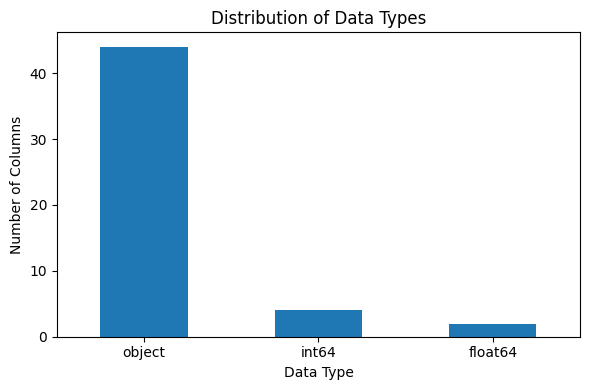

In [106]:
# Count of each data type
dtype_summary = train.dtypes.value_counts()

plt.figure(figsize=(6,4))
dtype_summary.plot(kind="bar")

plt.title("Distribution of Data Types")
plt.xlabel("Data Type")
plt.ylabel("Number of Columns")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [107]:
duplicates = train.duplicated().sum()

print(f"Duplicate rows : {duplicates}")

Duplicate rows : 0


In [108]:
missing = (train.isnull().sum() / len(train)) * 100
missing = missing.sort_values(ascending=False)
missing

col19                        99.952416
col18                        99.952416
col5                         92.515555
col4                         92.515555
col27                        89.214930
col28                        89.214930
col29                        86.393753
col30                        86.393753
col13                        83.125572
col14                        83.125572
col7                         83.125572
col6                         83.125572
col9                         83.125572
col8                         83.125572
col11                        83.125572
col3                         78.909309
Forks                        78.861724
Spec_ReleaseSeries           76.282795
col1                         75.641127
col12                        72.340502
col15                        69.519326
DrivetrainType               64.856057
UtilizationTier              63.608770
Spec_VariantModifier         62.269919
col20                        48.799216
col25                    

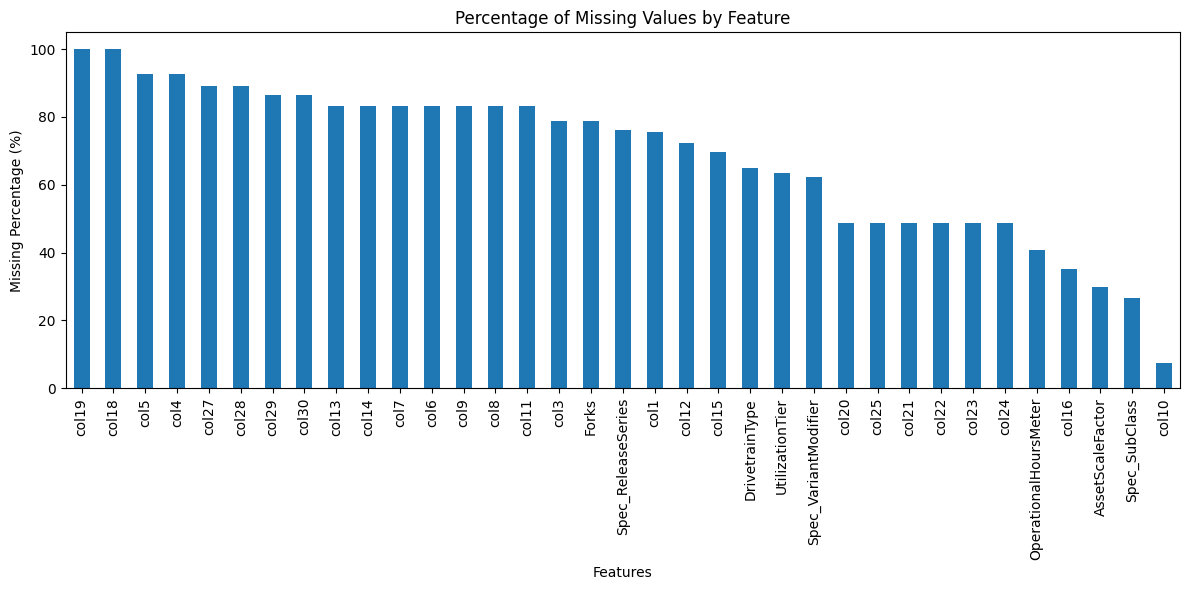

In [109]:
missing = missing[missing>0]
plt.figure(figsize=(12,6))
missing.plot(kind="bar")
plt.title("Percentage of Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [110]:
print(train["TargetValue"].describe())

print(f"Skewness : {train['TargetValue'].skew():.2f}")

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64
Skewness : 0.97


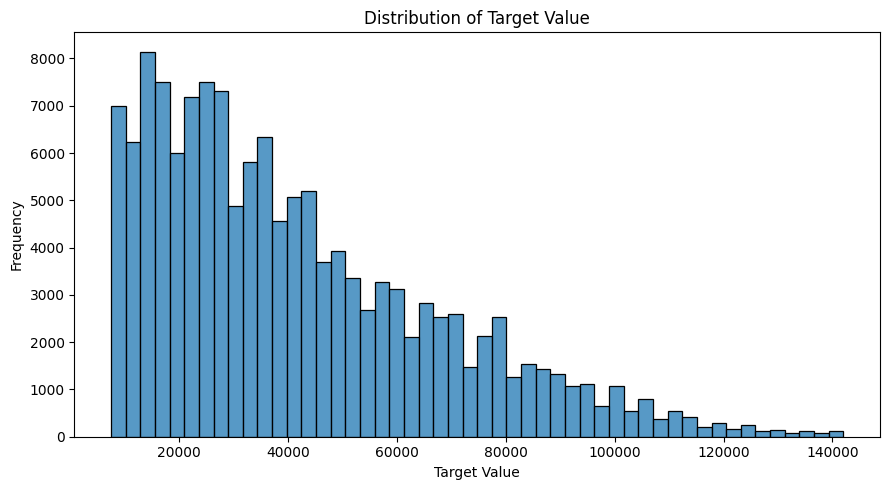

In [111]:
plt.figure(figsize=(9,5))
sns.histplot(
    train["TargetValue"],
    bins=50,
    
)

plt.title("Distribution of Target Value")

plt.xlabel("Target Value")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

### Observation
It is showing a univariate price distribution.
The target variable exhibits a positively skewed distribution with a small number of very high values. The positive skewness indicates that the data is not normally distributed, making a logarithmic transformation suitable before model training.

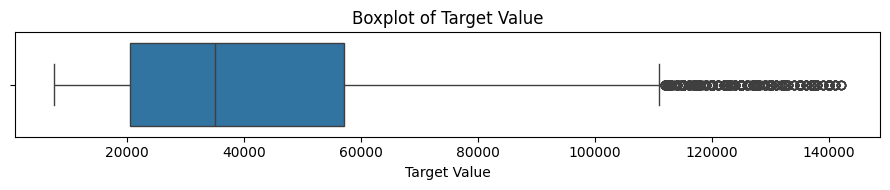

In [112]:
plt.figure(figsize=(9,2))

sns.boxplot(
    x=train["TargetValue"]
)

plt.title("Boxplot of Target Value")

plt.xlabel("Target Value")

plt.tight_layout()

plt.show()

### Observation

The boxplot indicates the presence of several high-value observations. These are expected in equipment pricing datasets and were retained because tree-based models such as CatBoost, LightGBM and XGBoost are generally robust to outliers.

In [113]:
train["col18"].value_counts(dropna=False)

col18
NaN                    138635
None or Unspecified        57
Yes                         9
Name: count, dtype: int64

In [114]:
train["VendorPartnerID"]

0         GTX
1         GTX
2         GTX
3         GTX
4         GTX
         ... 
138696    MPF
138697    MPF
138698    MPF
138699    MPF
138700    MPF
Name: VendorPartnerID, Length: 138701, dtype: object

In [115]:
train["col22"].nunique()

27

In [116]:
train["DrivetrainType"].value_counts().head()

DrivetrainType
None or Unspecified    21482
Standard               20072
Powershift              4700
Hydrostatic             1398
Powershuttle            1006
Name: count, dtype: int64

In [117]:
for col in ["TransactionID", "AssetID", "ProductConfigID", "VendorPartnerID"]:
    print(f"{col}: {train[col].nunique()} unique values")

TransactionID: 138701 unique values
AssetID: 120111 unique values
ProductConfigID: 3594 unique values
VendorPartnerID: 31 unique values


In [118]:
train['TransactionDate']

0         2005-03-26
1         2009-12-18
2         2005-08-26
3         2006-11-17
4         2010-08-27
             ...    
138696    2013-03-07
138697    2013-01-28
138698    2013-01-28
138699    2013-03-07
138700    2013-01-28
Name: TransactionDate, Length: 138701, dtype: object

In [119]:
train["OperationalHoursMeter"].describe()

count    8.205800e+04
mean     4.553719e+03
std      2.792204e+04
min      0.000000e+00
25%      0.000000e+00
50%      1.620000e+03
75%      5.001000e+03
max      1.729600e+06
Name: OperationalHoursMeter, dtype: float64

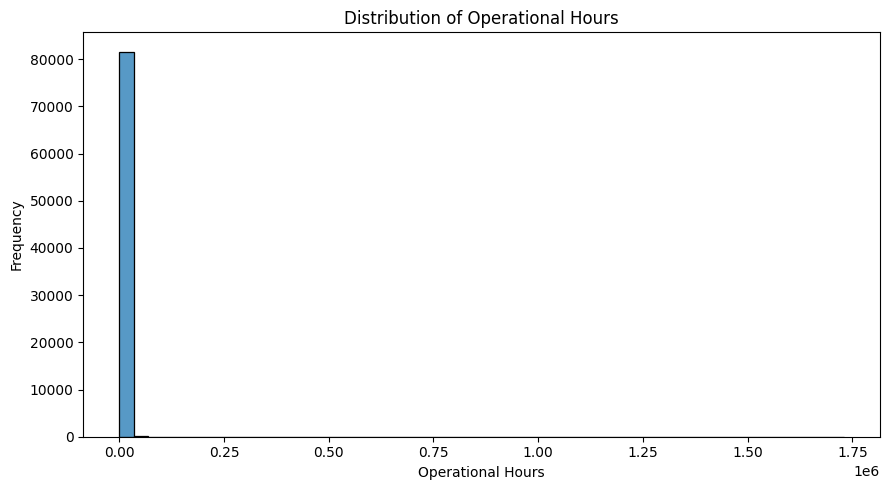

In [120]:
plt.figure(figsize=(9,5))

sns.histplot(
    train["OperationalHoursMeter"],
    bins=50,
    
)

plt.title("Distribution of Operational Hours")

plt.xlabel("Operational Hours")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

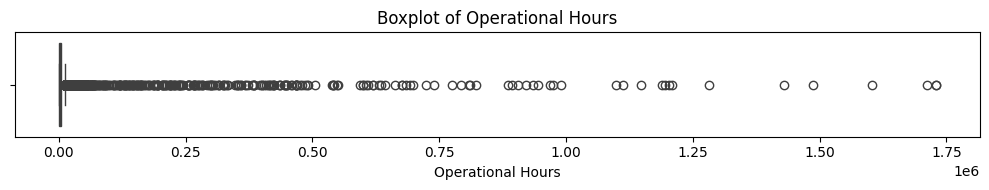

In [121]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=train["OperationalHoursMeter"]
)

plt.title("Boxplot of Operational Hours")

plt.xlabel("Operational Hours")

plt.tight_layout()

plt.show()

### Observation

The operational hours feature is highly right-skewed with several extreme values. A large proportion of machines have relatively low recorded operating hours, while a smaller number exhibit exceptionally high usage. Median imputation is therefore more appropriate than mean imputation for handling missing values.

Most machines here have relatively low operational hours
and few have extreme causing the graph to indicate outliers

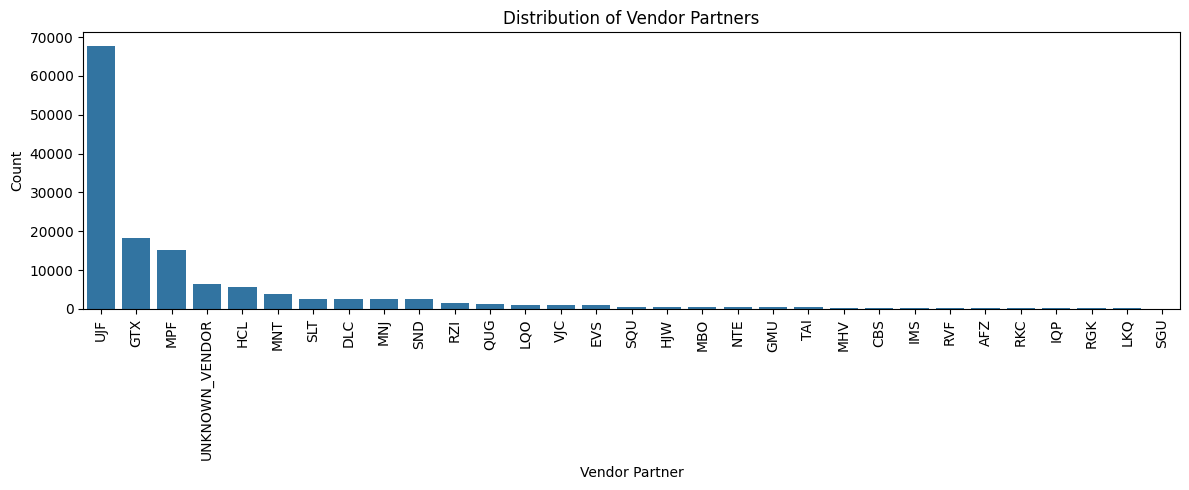

In [122]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=train,
    x="VendorPartnerID",
    order=train["VendorPartnerID"].value_counts().index
)

plt.title("Distribution of Vendor Partners")
plt.xlabel("Vendor Partner")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [123]:
train["FunctionalClassification"].describe()

count                                                138701
unique                                                   65
top       Hydraulic Excavator, Track - 21.0 to 24.0 Metr...
freq                                                  11158
Name: FunctionalClassification, dtype: object

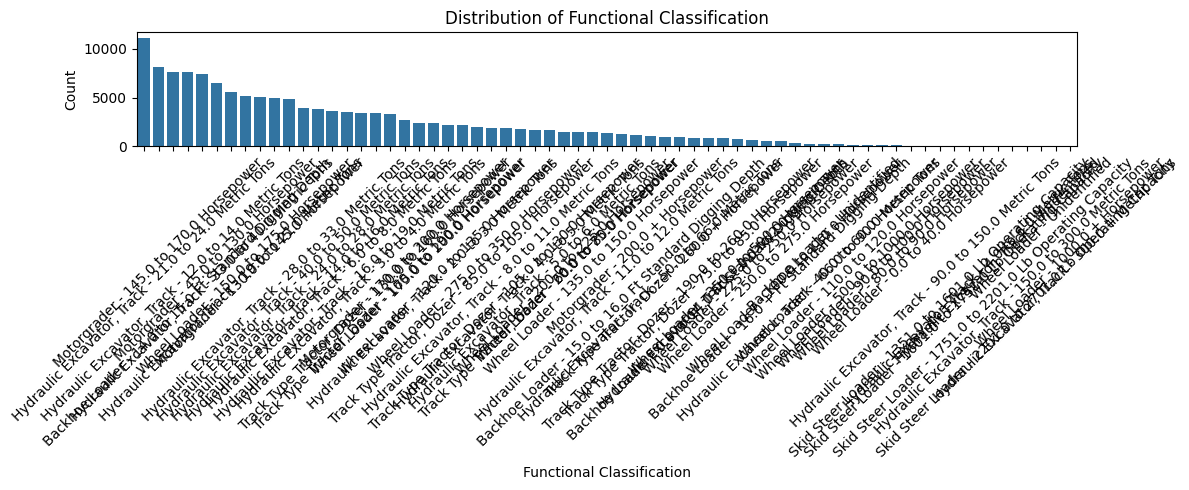

In [124]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=train,
    x="FunctionalClassification",
    order=train["FunctionalClassification"].value_counts().index
)

plt.title("Distribution of Functional Classification")
plt.xlabel("Functional Classification")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

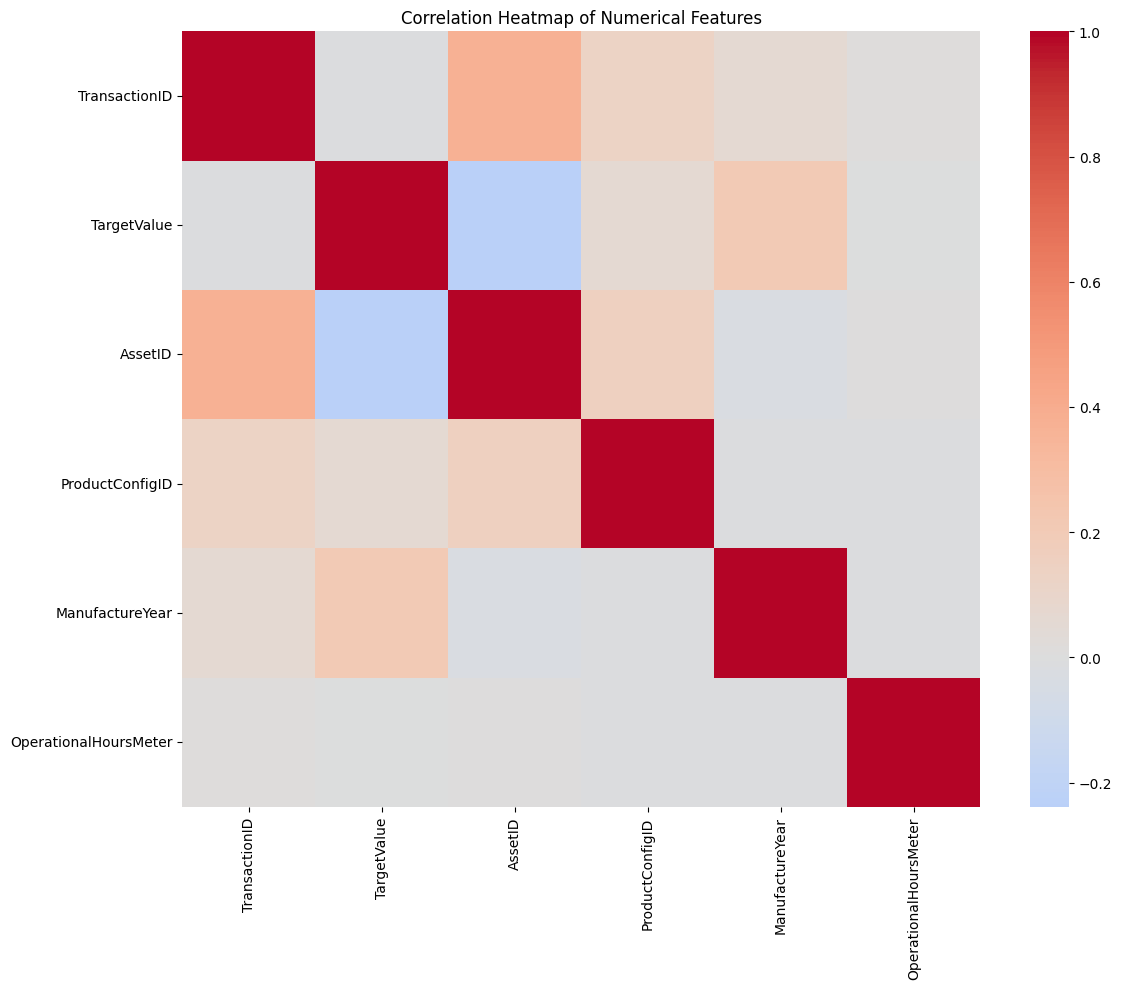

In [125]:
numerical_cols = train.select_dtypes(include=np.number).columns

corr = train[numerical_cols].corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")

plt.tight_layout()

plt.show()

In [126]:
train["TargetValue"].describe()

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

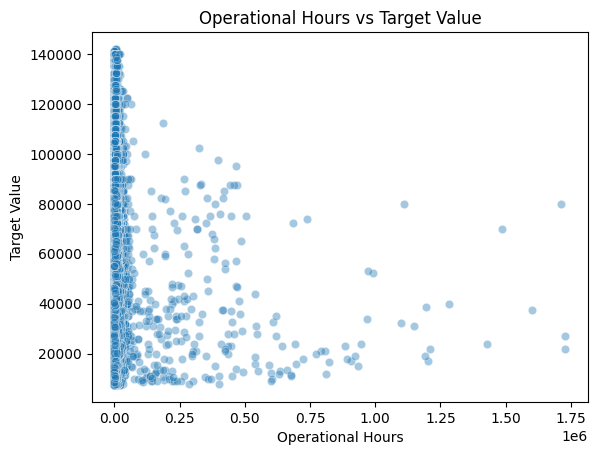

In [127]:
sns.scatterplot(
    data=train,
    x="OperationalHoursMeter",
    y="TargetValue",
    alpha=0.4
)

plt.title("Operational Hours vs Target Value")
plt.xlabel("Operational Hours")
plt.ylabel("Target Value")
plt.show()

### Observation
We are trying to find whether equipment with higher usage sell for less

In [128]:
train.nunique().sort_values(ascending=False)


TransactionID                138701
AssetID                      120111
OperationalHoursMeter         14643
TransactionDate                3676
ProductConfigID                3594
Spec_FullDescriptor            3505
Spec_BaseClass                 1249
TargetValue                     675
Spec_SubClass                   147
Spec_VariantModifier            132
Spec_ReleaseSeries              113
ManufactureYear                  68
FunctionalClassification         65
RegionCode                       53
VendorPartnerID                  31
col22                            27
col21                            18
col15                            15
col10                            11
col27                             9
DrivetrainType                    8
DataOriginCode                    6
col7                              6
AssetScaleFactor                  6
InventoryGroupDescription         6
InventoryGroupCategory            6
col28                             5
col1                        

# **Preproccessing** ##

In [129]:
print(train.columns)

Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'DataOriginCode', 'VendorPartnerID', 'ManufactureYear',
       'OperationalHoursMeter', 'UtilizationTier', 'TransactionDate',
       'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass',
       'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor',
       'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory',
       'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3',
       'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9',
       'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col18',
       'col19', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27',
       'col28', 'col29', 'col30'],
      dtype='object')


In [130]:
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])

test["TransactionDate"] = pd.to_datetime(test["TransactionDate"])


In [131]:
train['TransactionDate'].dtype


dtype('<M8[ns]')

# Feature Engineering ##


In [132]:
train["TransactionYear"]=train["TransactionDate"].dt.year

In [133]:
train["TransactionMonth"]=train["TransactionDate"].dt.month

In [134]:
test["TransactionYear"] = test["TransactionDate"].dt.year
test["TransactionMonth"] = test["TransactionDate"].dt.month

After extracting the useful temporal features (TransactionYear and TransactionMonth), the original TransactionDate no longer provides additional information. Keeping it would be redundant, so it is dropped.

In [135]:
train["ManufactureYear"] = train["ManufactureYear"].replace([1000, 1001], np.nan)
test["ManufactureYear"] = test["ManufactureYear"].replace([1000, 1001], np.nan)

In [136]:
train["AssetAge"] = train["TransactionYear"] - train["ManufactureYear"]
test["AssetAge"] = test["TransactionYear"] - test["ManufactureYear"]

In [137]:
train["TransactionQuarter"] = train["TransactionDate"].dt.quarter
test["TransactionQuarter"] = test["TransactionDate"].dt.quarter

In [138]:
train.drop(columns=["TransactionDate"], inplace=True)
test.drop(columns=["TransactionDate"], inplace=True)

In [139]:
train[["ManufactureYear", "AssetAge"]].head()

,ManufactureYear,AssetAge
0,1997.0,8.0
1,2005.0,4.0
2,1994.0,11.0
3,2002.0,4.0
4,2009.0,1.0


In [140]:
train[["ManufactureYear", "AssetAge"]].isnull().sum()

ManufactureYear    14719
AssetAge           14719
dtype: int64

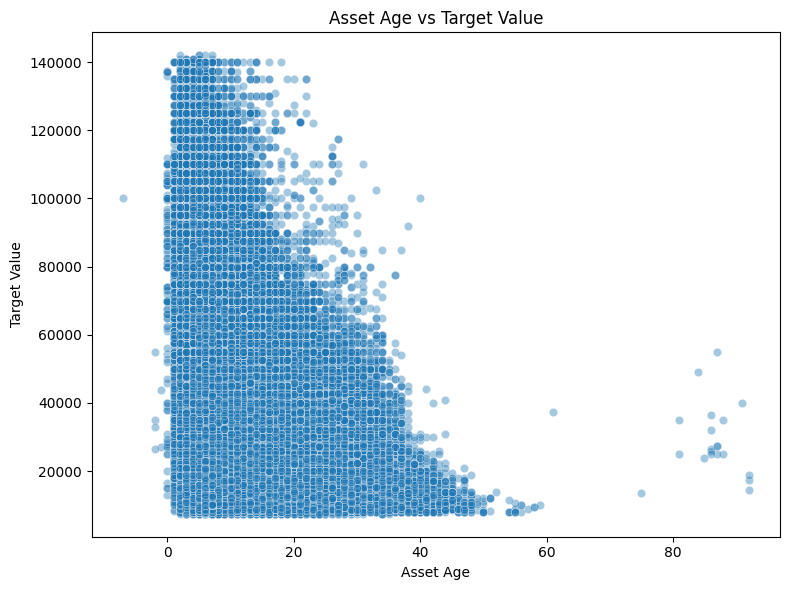

In [141]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=train,
    x="AssetAge",
    y="TargetValue",
    alpha=0.4
)

plt.title("Asset Age vs Target Value")
plt.xlabel("Asset Age")
plt.ylabel("Target Value")

plt.tight_layout()
plt.show()

### Observation 
To see whether older equipment correlates with lower price

# Handling Missing Values ##

In [142]:
high_missing = [
    "col4","col5","col18","col19",
    "col27","col28","col29","col30"
]

for col in high_missing:
    print(f"\n{'='*40}")
    print(col)
    print(train[col].value_counts(dropna=False))


col4
col4
NaN         128320
Standard      5330
Extended      5051
Name: count, dtype: int64

col5
col5
NaN                    128320
None or Unspecified      9911
Yes                       470
Name: count, dtype: int64

col18
col18
NaN                    138635
None or Unspecified        57
Yes                         9
Name: count, dtype: int64

col19
col19
NaN          138635
Standard         65
High Flow         1
Name: count, dtype: int64

col27
col27
NaN                    123742
PAT                      7091
Semi U                   2293
None or Unspecified      1870
VPAT                     1702
Straight                 1661
Angle                     209
U                         118
Landfill                   14
Coal                        1
Name: count, dtype: int64

col28
col28
NaN                    123742
None or Unspecified     10537
Differential Steer       2850
Finger Tip               1212
Lever                     320
Pedal                      40
Name: count, dtype:

Here we see col18 and col19 having less concrete data...wouldnt help in building the model

In [143]:
train.drop(columns=["TransactionID", "col18", "col19"], inplace=True)

test.drop(columns=["TransactionID",  "col18", "col19"], inplace=True)

### Numerical Imputation


In [144]:

#median_hours = train["OperationalHoursMeter"].median()

#train["OperationalHoursMeter"] = train["OperationalHoursMeter"].fillna(median_hours)
#test["OperationalHoursMeter"] = test["OperationalHoursMeter"].fillna(median_hours)

#### No numerical imputation
Numerical missing values (OperationalHoursMeter, AssetAge, ManufactureYear) were intentionally left as NaN. CatBoost, LightGBM, and XGBoost all handle missing values natively during tree splits, so explicit imputation was unnecessary and risks losing information

### Categorical Imputation

In [145]:
# getting all cateorical columns

cat_cols = train.select_dtypes(include="object").columns

# Fill missing values in train
for col in cat_cols:
    train[col] = train[col].fillna("Unknown")

# Fill missing values in test
for col in cat_cols:
    test[col] = test[col].fillna("Unknown")

In [146]:
train.isnull().sum().sort_values(ascending=False).head(10)

OperationalHoursMeter    56643
ManufactureYear          14719
AssetAge                 14719
AssetID                      0
DataOriginCode               0
TargetValue                  0
VendorPartnerID              0
UtilizationTier              0
Spec_FullDescriptor          0
ProductConfigID              0
dtype: int64

In [147]:
test.isnull().sum().sort_values(ascending=False).head(10)

OperationalHoursMeter    6191
ManufactureYear          1580
AssetAge                 1580
DataOriginCode              0
AssetID                     0
VendorPartnerID             0
UtilizationTier             0
Spec_FullDescriptor         0
ProductConfigID             0
Spec_SubClass               0
dtype: int64

In [148]:
train.loc[train["AssetAge"] <= 0, "AssetAge"] = np.nan
test.loc[test["AssetAge"] <= 0, "AssetAge"] = np.nan

Age cannot be negative so we imputed it to be np.nan

In [149]:
train["HoursPerYear"] = (
    train["OperationalHoursMeter"] /
    train["AssetAge"]
)

test["HoursPerYear"] = (
    test["OperationalHoursMeter"] /
    test["AssetAge"]
)

In [150]:
print(train["HoursPerYear"].describe())

print(np.isinf(train["HoursPerYear"]).sum())

print(train["HoursPerYear"].isnull().sum())

count     72812.000000
mean        623.213584
std        4021.307893
min           0.000000
25%           0.000000
50%         320.000000
75%         715.754808
max      228985.714286
Name: HoursPerYear, dtype: float64
0
65889


In [151]:
(train["AssetAge"] < 0).sum()

np.int64(0)

In [152]:
(train["AssetAge"] == 0).sum()

np.int64(0)

In [153]:
train["HoursPerYear"] = train["HoursPerYear"].replace([np.inf, -np.inf], np.nan)
test["HoursPerYear"] = test["HoursPerYear"].replace([np.inf, -np.inf], np.nan)

In [154]:
print(np.isinf(train["HoursPerYear"]).sum())
print((train["HoursPerYear"] < 0).sum())
print(train["HoursPerYear"].isnull().sum())

0
0
65889


In [155]:
train["HoursPerYear"].describe(percentiles=[0.95, 0.99])

count     72812.000000
mean        623.213584
std        4021.307893
min           0.000000
50%         320.000000
95%        1438.451667
99%        2305.670000
max      228985.714286
Name: HoursPerYear, dtype: float64

Used it to examine the stats of hoursperyear and tried to identify the range in which most observation lies and detect extreme values.
Std shows the data is highly spread out and distribution is right skewed

### Feature Engineering Summary

The following feature engineering steps were performed:

- Converted TransactionDate into datetime format.
- Extracted TransactionYear from the transaction date.
- Extracted TransactionMonth from the transaction date.
- Created AssetAge to represent equipment age at the time of sale.
- Treated invalid manufacturing years as missing values.
- Removed the original TransactionDate column after extracting the required information.

These engineered features provide additional temporal and age-related information that can improve the model's ability to predict the target value.

Feature scaling (standardization/normalization) was not applied because all three models used (CatBoost, LightGBM, XGBoost) are tree-based and split on raw feature values — they are scale-invariant, so scaling would have no effect on model performance.

# Model Building
Here we will train three models mainly catboost,xgboost ,lightgbm 
They were chosen to compare how each library's specific optimizations (native categorical handling, leaf-wise vs level-wise growth, histogram binning) affect performance on the same tabular dataset, rather than to demonstrate algorithmic diversity.

## Catboost

In [156]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_log_error
import numpy as np


In [157]:
X = train.drop(columns=["TargetValue"])
y = train["TargetValue"]

In [158]:
y_log = np.log1p(y)

In [159]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

In [160]:
cat_features = X_train.select_dtypes(include="object").columns.tolist()

In [161]:
print(cat_features)

['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


In [162]:
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=100
)

In [163]:
print(X_train.isnull().sum().sum())
print(X_valid.isnull().sum().sum())

121486
30600


In [164]:


model.fit(
    X_train,
    y_train,
    cat_features=cat_features,
    eval_set=(X_valid, y_valid),
    use_best_model=True,
    early_stopping_rounds=100
)

0:	learn: 0.6489708	test: 0.6469550	best: 0.6469550 (0)	total: 891ms	remaining: 14m 50s
100:	learn: 0.2649330	test: 0.2581369	best: 0.2581369 (100)	total: 1m 19s	remaining: 11m 51s
200:	learn: 0.2458868	test: 0.2399793	best: 0.2399793 (200)	total: 2m 46s	remaining: 11m 2s
300:	learn: 0.2338211	test: 0.2300844	best: 0.2300844 (300)	total: 4m 16s	remaining: 9m 55s
400:	learn: 0.2271096	test: 0.2249055	best: 0.2249055 (400)	total: 5m 45s	remaining: 8m 35s
500:	learn: 0.2224333	test: 0.2216270	best: 0.2216270 (500)	total: 7m 12s	remaining: 7m 11s
600:	learn: 0.2187407	test: 0.2193547	best: 0.2193547 (600)	total: 8m 41s	remaining: 5m 46s
700:	learn: 0.2155710	test: 0.2173581	best: 0.2173581 (700)	total: 10m 11s	remaining: 4m 20s
800:	learn: 0.2130390	test: 0.2159745	best: 0.2159745 (800)	total: 11m 40s	remaining: 2m 53s
900:	learn: 0.2108901	test: 0.2148738	best: 0.2148738 (900)	total: 13m 8s	remaining: 1m 26s
999:	learn: 0.2087163	test: 0.2137922	best: 0.2137922 (999)	total: 14m 37s	remain

CatBoostRegressor(depth=8, eval_metric='RMSE', iterations=1000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

## LighGBM 

In [165]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_log_error

In [166]:
cat_cols = X_train.select_dtypes(include="object").columns.tolist()

In [167]:
for col in cat_cols:
    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")
    test[col] = test[col].astype("category")

In [168]:
lgb_model = LGBMRegressor(
    n_estimators=4000,
    learning_rate=0.02,
    max_depth=-1,
    num_leaves=256,
    feature_fraction=0.75,
    random_state=42,
    verbosity=-1
)

In [169]:
from lightgbm import early_stopping

lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(100, verbose=True)
    ]
)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[3161]	valid_0's rmse: 0.198139	valid_0's l2: 0.039259


LGBMRegressor(feature_fraction=0.75, learning_rate=0.02, n_estimators=4000,
              num_leaves=256, random_state=42, verbosity=-1)

In [170]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred_log = lgb_model.predict(X_valid)

rmse = np.sqrt(mean_squared_error(y_valid, y_pred_log))

print("Validation RMSE:", rmse)

Validation RMSE: 0.19813885900843037


In [171]:
print(lgb_model)

LGBMRegressor(feature_fraction=0.75, learning_rate=0.02, n_estimators=4000,
              num_leaves=256, random_state=42, verbosity=-1)


In [172]:
pred_log = lgb_model.predict(test)

pred = np.expm1(pred_log)

<Figure size 1000x800 with 0 Axes>

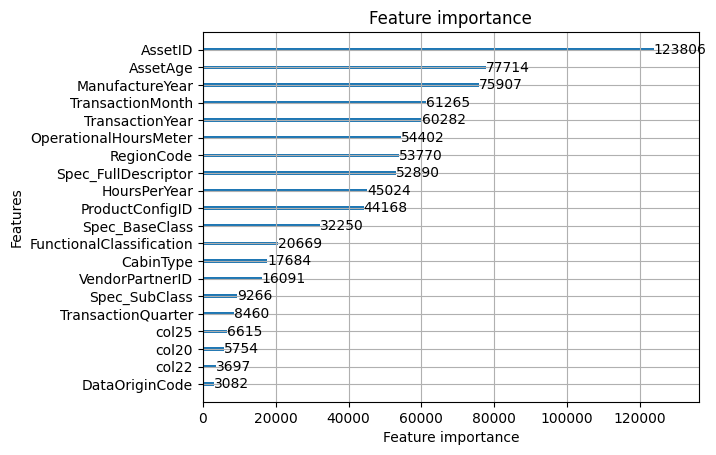

In [173]:
import matplotlib.pyplot as plt
from lightgbm import plot_importance

plt.figure(figsize=(10,8))
plot_importance(lgb_model, max_num_features=20)
plt.show()

## Hyperparameter Tuning using RandomizedSearchCV

After manually tuning the LightGBM model, RandomizedSearchCV was used to automatically explore different combinations of important hyperparameters. This approach evaluates a random subset of parameter combinations, making it computationally more efficient than GridSearchCV while still identifying strong-performing configurations.

In [174]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor

param_dist = {
    "num_leaves": [64, 128, 256],
    "learning_rate": [0.01, 0.02, 0.03],
    "max_depth": [8, 10, -1],
    "feature_fraction": [0.7, 0.75, 0.8]
}

random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(
        n_estimators=1000,
        random_state=123,
        verbosity=-1
    ),
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest Validation Score:")
print(-random_search.best_score_)

Best Parameters:
{'num_leaves': 128, 'max_depth': 10, 'learning_rate': 0.03, 'feature_fraction': 0.7}

Best Validation Score:
0.21072486981055658


## Xgboost

In [175]:
from xgboost import XGBRegressor
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [176]:
cat_cols = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

print(len(cat_cols), len(num_cols))

41 50


## Preprocessing Pipeline

Since XGBoost cannot directly process categorical string values, a preprocessing pipeline was created using ColumnTransformer and OrdinalEncoder.

The pipeline ensures that identical preprocessing steps are consistently applied to both the training and validation/test datasets, improving reproducibility while reducing redundant preprocessing code.

A Pipeline/ColumnTransformer was used only for XGBoost because it requires pre-encoded numeric input. CatBoost and LightGBM were handled outside a formal Pipeline since both support categorical features natively (via cat_features and pandas category dtype respectively), making a ColumnTransformer unnecessary for them.

In [177]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            cat_cols
        )
    ],
    remainder="passthrough"
)

In [178]:
xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.02,
    max_depth=10,
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

In [179]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

In [180]:
xgb_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['DataOriginCode',
                                                   'VendorPartnerID',
                                                   'UtilizationTier',
                                                   'Spec_FullDescriptor',
                                                   'Spec_BaseClass',
                                                   'Spec_SubClass',
                                                   'Spec_ReleaseSeries',
                                                   'Spec_VariantModifier',
                                                   'AssetScaleFactor',
                                                   'FunctionalClas...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.02,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=10, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=3000, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [181]:
y_pred_log = xgb_pipeline.predict(X_valid)

validation_rmsle = np.sqrt(mean_squared_error(y_valid, y_pred_log))

print("Validation RMSLE:", validation_rmsle)

Validation RMSLE: 0.20461979297459748


## Ensemble 

In [182]:
# LightGBM predictions
lgb_pred = lgb_model.predict(X_valid)

# XGBoost predictions
xgb_pred = xgb_pipeline.predict(X_valid)

ensemble_pred = (lgb_pred + xgb_pred) / 2

from sklearn.metrics import mean_squared_error
import numpy as np

ensemble_rmse = np.sqrt(
    mean_squared_error(y_valid, ensemble_pred)
)

print("Ensemble RMSE:", ensemble_rmse)

Ensemble RMSE: 0.19601735573085238


In [183]:
print(X_train.shape)
print(X_valid.shape)

(110960, 50)
(27741, 50)


In [184]:
print(len(cat_cols))
print(cat_cols)

41
['DataOriginCode', 'VendorPartnerID', 'UtilizationTier', 'Spec_FullDescriptor', 'Spec_BaseClass', 'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier', 'AssetScaleFactor', 'FunctionalClassification', 'RegionCode', 'InventoryGroupCategory', 'InventoryGroupDescription', 'col1', 'CabinType', 'Forks', 'col3', 'col4', 'DrivetrainType', 'col5', 'col6', 'col7', 'col8', 'col9', 'col10', 'col11', 'col12', 'col13', 'col14', 'col15', 'col16', 'col20', 'col21', 'col22', 'col23', 'col24', 'col25', 'col27', 'col28', 'col29', 'col30']


# Model Selection

The performance of all trained models was evaluated using the validation dataset.

The model with the lowest validation RMSLE was selected for final prediction on the unseen test dataset."

In [185]:
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

# Validation predictions
cat_pred = model.predict(X_valid)
lgb_pred = lgb_model.predict(X_valid)
xgb_pred = xgb_pipeline.predict(X_valid)

ensemble_pred = (lgb_pred + xgb_pred) / 2
# Validation RMSLE (RMSE on log-transformed targets)
scores = {
    "CatBoost": np.sqrt(mean_squared_error(y_valid, cat_pred)),
    "LightGBM": np.sqrt(mean_squared_error(y_valid, lgb_pred)),
    "XGBoost": np.sqrt(mean_squared_error(y_valid, xgb_pred)),
    "LightGBM + XGBoost": np.sqrt(mean_squared_error(y_valid, ensemble_pred))
}



In [186]:
comparison = (
    pd.DataFrame(scores.items(), columns=["Model", "Validation_RMSLE"])
    .sort_values("Validation_RMSLE")
    .reset_index(drop=True)
)

comparison

,Model,Validation_RMSLE
0,LightGBM + XGBoost,0.196017
1,LightGBM,0.198139
2,XGBoost,0.204620
3,CatBoost,0.213792


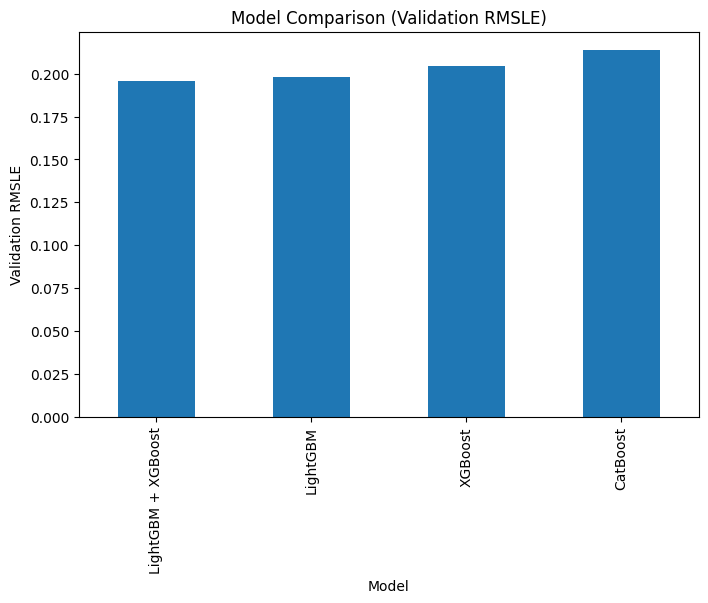

In [187]:
import matplotlib.pyplot as plt

comparison.plot(
    x="Model",
    y="Validation_RMSLE",
    kind="bar",
    legend=False,
    figsize=(8,5),
    title="Model Comparison (Validation RMSLE)"
)

plt.ylabel("Validation RMSLE")
plt.show()

# Submission 

In [188]:
# Select best model
best_model = comparison.loc[0, "Model"]

print(f"Selected Final Model: {best_model}")

# Generate test predictions
if best_model == "CatBoost":
    test_pred_log = model.predict(test)

elif best_model == "LightGBM":
    test_pred_log = lgb_model.predict(test)

elif best_model == "XGBoost":
    test_pred_log = xgb_pipeline.predict(test)

else:   # LightGBM + XGBoost Ensemble
    lgb_test = lgb_model.predict(test)
    xgb_test = xgb_pipeline.predict(test)
    test_pred_log = (lgb_test + xgb_test) / 2

# Convert back to original scale
test_pred = np.expm1(test_pred_log)

# Create submission file
submission = pd.DataFrame({
    "TransactionID": test_ids,
    "TargetValue": test_pred
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

submission.head()



Selected Final Model: LightGBM + XGBoost
submission.csv created successfully!


,TransactionID,TargetValue
0,1139307,61453.770653
1,1139419,77538.433193
2,1139482,32335.495411
3,1139522,21279.581446
4,1139684,10843.113805


# Conclusion

Three gradient boosting models (CatBoost, LightGBM and XGBoost) were trained and evaluated for heavy equipment selling price prediction.

Hyperparameter tuning improved the performance of the individual models, and an ensemble of LightGBM and XGBoost achieved the lowest validation RMSLE.

Based on the comparison, the ensemble model was selected to generate the final competition submission.